# Temporal Analysis

Time-based patterns in task volume, assignment timing, work duration, and punctuality.

In [11]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


,YEAR,task_count
0,1956.0,1
1,2009.0,25
2,2010.0,22411
3,2011.0,29909
4,2012.0,37033
5,2013.0,44621
6,2014.0,60920
7,2015.0,83962
8,2016.0,74634
9,2017.0,84563


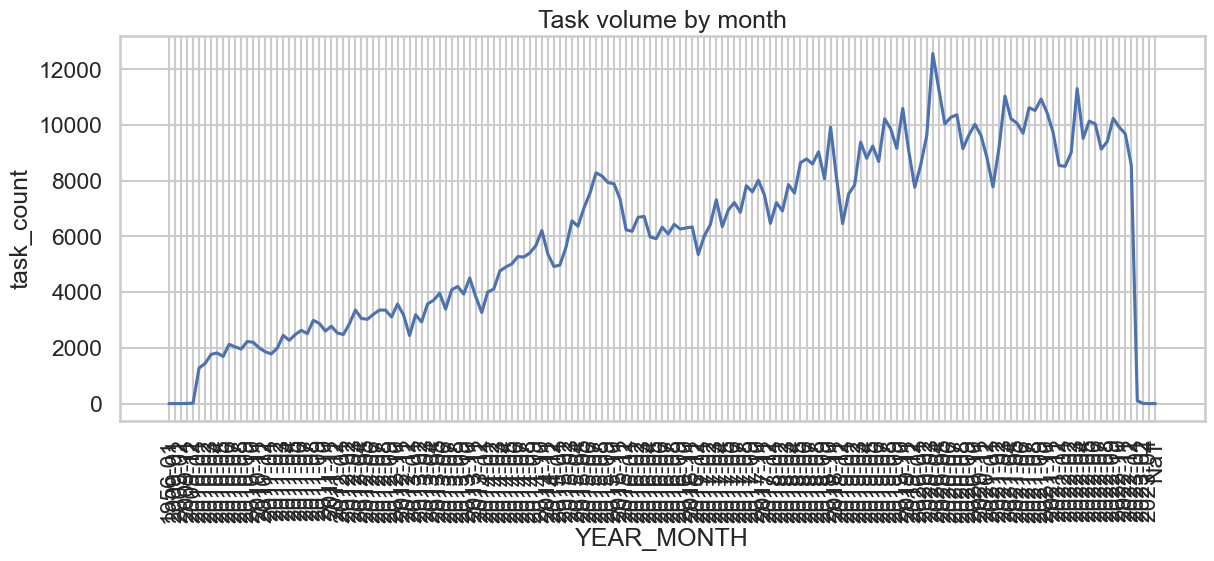

In [12]:
monthly_volume = (
    data.assign(YEAR_MONTH=data["START"].dt.to_period("M").astype(str))
    .groupby("YEAR_MONTH")
    .size()
    .rename("task_count")
    .reset_index()
)
yearly_volume = (
    data.assign(YEAR=data["START"].dt.year)
    .groupby("YEAR")
    .size()
    .rename("task_count")
    .reset_index()
)
display(yearly_volume)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_volume, x="YEAR_MONTH", y="task_count")
plt.xticks(rotation=90)
plt.title("Task volume by month")
plt.show()

,MONTH_NUM,MONTH_NAME,task_count
0,1.0,January,69649
1,2.0,February,74661
2,3.0,March,88676
3,4.0,April,81876
4,5.0,May,84222
5,6.0,June,85266
6,7.0,July,87456
7,8.0,August,88340
8,9.0,September,87689
9,10.0,October,92246


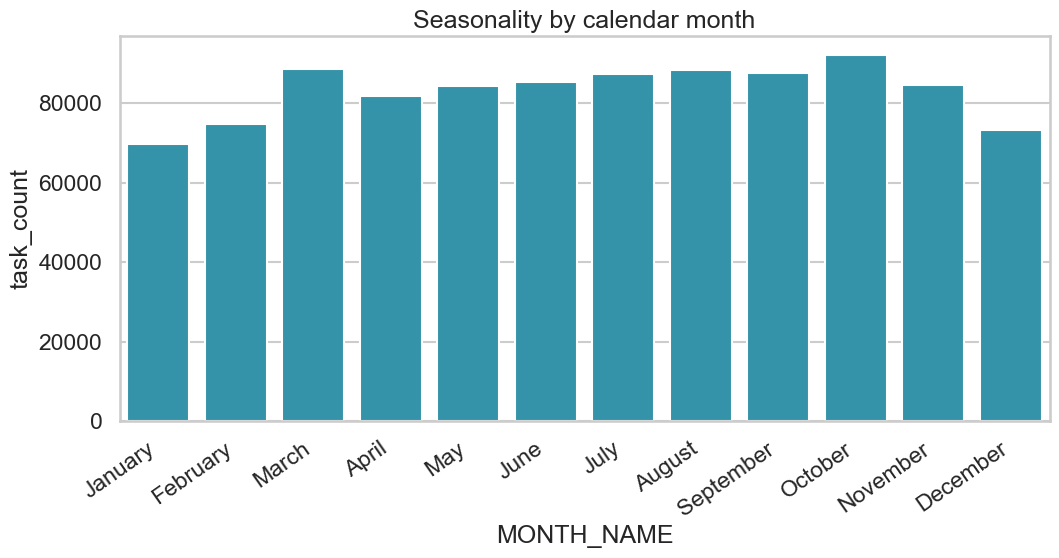

In [13]:
seasonality = (
    data.assign(MONTH_NAME=data["START"].dt.month_name())
    .groupby(["START", "MONTH_NAME"])
)
month_summary = (
    data.assign(MONTH_NUM=data["START"].dt.month, MONTH_NAME=data["START"].dt.month_name())
    .groupby(["MONTH_NUM", "MONTH_NAME"])
    .size()
    .rename("task_count")
    .reset_index()
    .sort_values("MONTH_NUM")
)
display(month_summary)

plt.figure(figsize=(12, 5))
sns.barplot(data=month_summary, x="MONTH_NAME", y="task_count", color="#219ebc")
plt.xticks(rotation=35, ha="right")
plt.title("Seasonality by calendar month")
plt.show()

,START_DOW,task_count
0,Monday,191243
1,Tuesday,198318
2,Wednesday,199291
3,Thursday,197193
4,Friday,186307
5,Saturday,16988
6,Sunday,8592


,ASSIGNED_HOUR,task_count
0,0,7654
1,1,4254
2,2,2425
3,3,1652
4,4,1401
5,5,1301
6,6,1954
7,7,10619
8,8,68730
9,9,126366


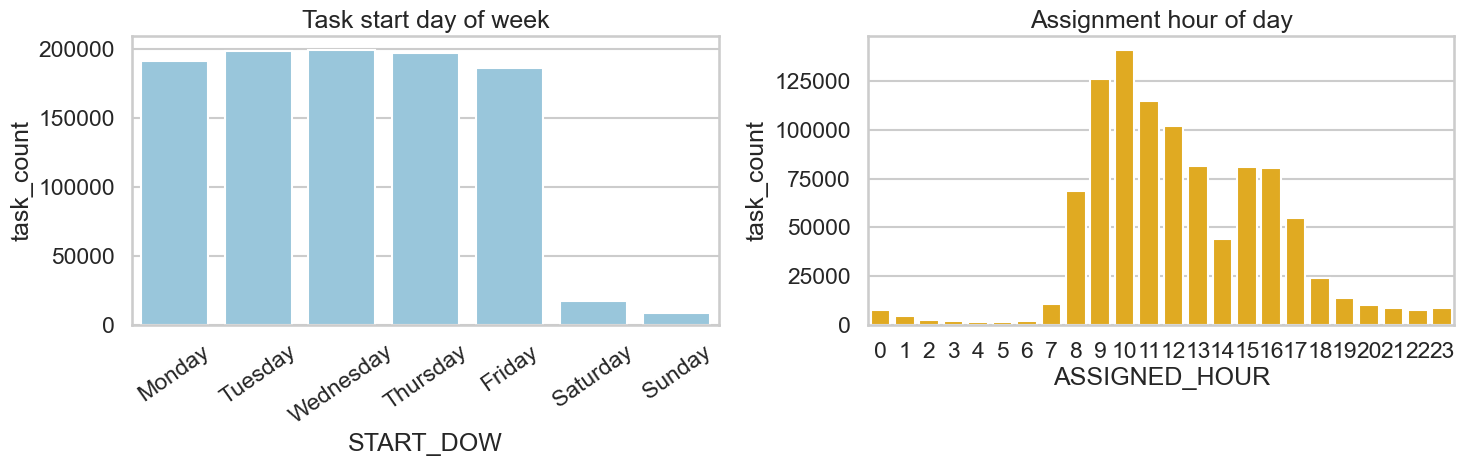

In [14]:
start_dow = (
    data.assign(START_DOW=data["START"].dt.day_name())
    .groupby("START_DOW")
    .size()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
    .rename("task_count")
    .reset_index()
)
display(start_dow)

assigned_hour = (
    data.assign(ASSIGNED_HOUR=data["ASSIGNED"].dt.hour)
    .groupby("ASSIGNED_HOUR")
    .size()
    .rename("task_count")
    .reset_index()
)
display(assigned_hour)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=start_dow, x="START_DOW", y="task_count", ax=axes[0], color="#8ecae6")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Task start day of week")
sns.barplot(data=assigned_hour, x="ASSIGNED_HOUR", y="task_count", ax=axes[1], color="#ffb703")
axes[1].set_title("Assignment hour of day")
plt.tight_layout()
plt.show()

,TIME_TO_START_HOURS,TIME_TO_ASSIGN_HOURS,TASK_DURATION_HOURS,ACTUAL_WORKING_HOURS,LATENESS_MINUTES,TASK_TYPE_CLEAN
count,997933.000000,997932.000000,997930.000000,997933.000000,9.979330e+05,997933
unique,NaN,NaN,NaN,NaN,NaN,13
top,NaN,NaN,NaN,NaN,NaN,ProofReading
freq,NaN,NaN,NaN,NaN,NaN,430554
mean,17.200016,13.566909,59.580702,11.454268,1.858780e+02,NaN
std,54.189279,661.797316,727.163293,63.421928,7.574396e+03,NaN
min,0.000000,-17514.051389,-17493.000000,0.000000,0.000000e+00,NaN
25%,0.072500,0.006667,5.000000,0.000833,0.000000e+00,NaN
50%,1.925556,0.263056,20.850833,0.218056,0.000000e+00,NaN
75%,16.560278,4.986389,56.333333,1.794722,0.000000e+00,NaN


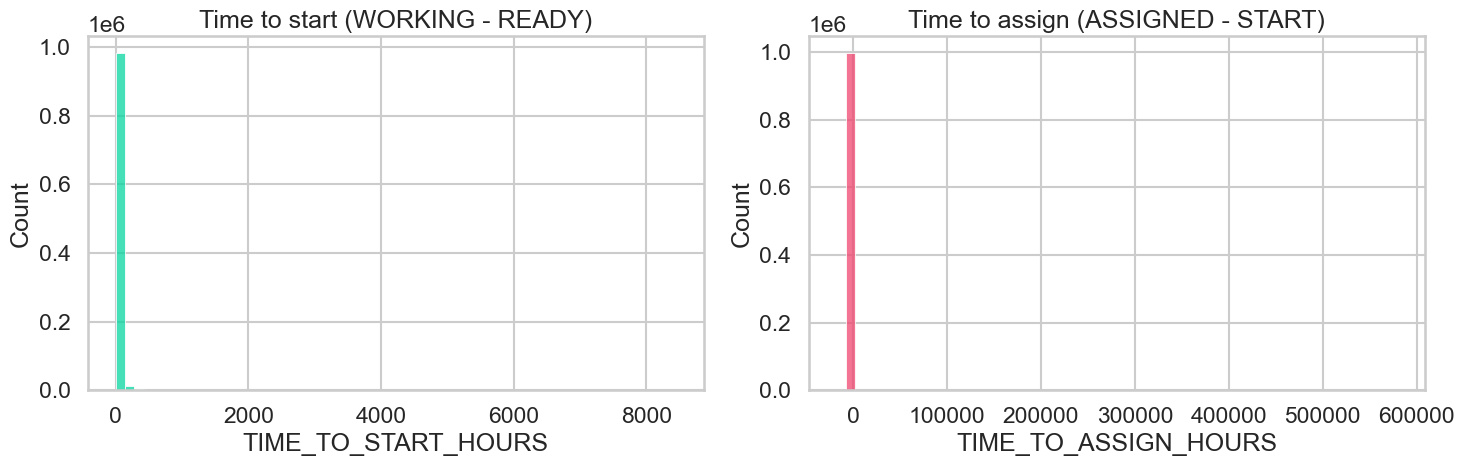

,metric,value
0,Tasks assigned before START (%),23.94


In [15]:
enriched = load_enriched_tasks()
timing_metrics = enriched[
    [
        "TIME_TO_START_HOURS",
        "TIME_TO_ASSIGN_HOURS",
        "TASK_DURATION_HOURS",
        "ACTUAL_WORKING_HOURS",
        "LATENESS_MINUTES",
        "TASK_TYPE_CLEAN",
    ]
].copy()
display(timing_metrics.describe(include="all"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(timing_metrics["TIME_TO_START_HOURS"].dropna(), bins=60, ax=axes[0], color="#06d6a0")
axes[0].set_title("Time to start (WORKING - READY)")
sns.histplot(timing_metrics["TIME_TO_ASSIGN_HOURS"].dropna(), bins=60, ax=axes[1], color="#ef476f")
axes[1].set_title("Time to assign (ASSIGNED - START)")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                "metric": "Tasks assigned before START (%)",
                "value": round((timing_metrics["TIME_TO_ASSIGN_HOURS"] < 0).mean() * 100, 2),
            }
        ]
    )
)

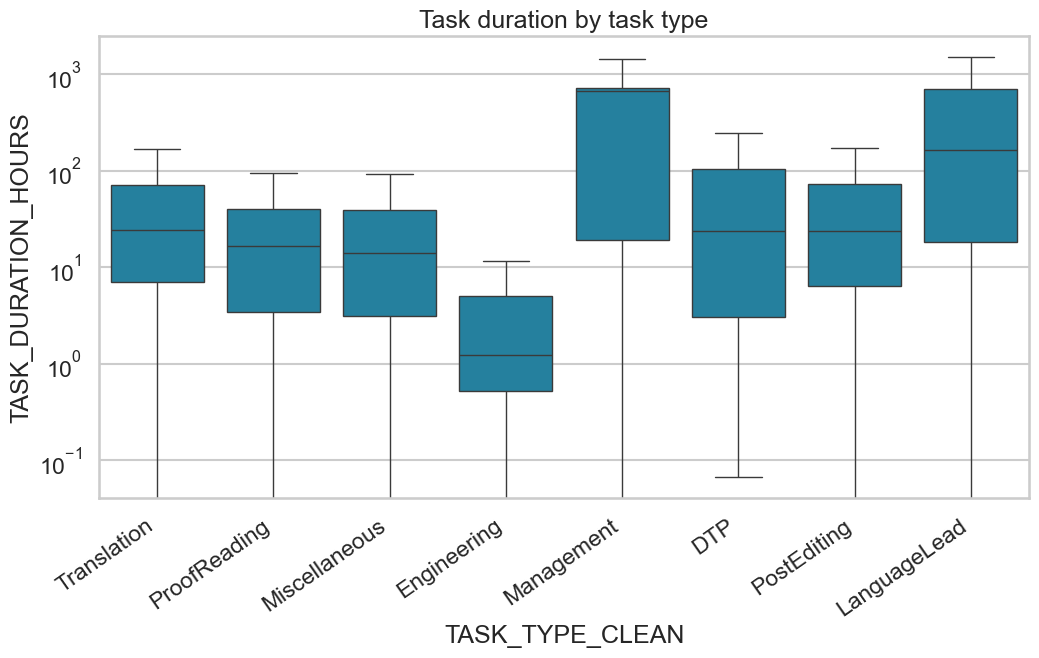

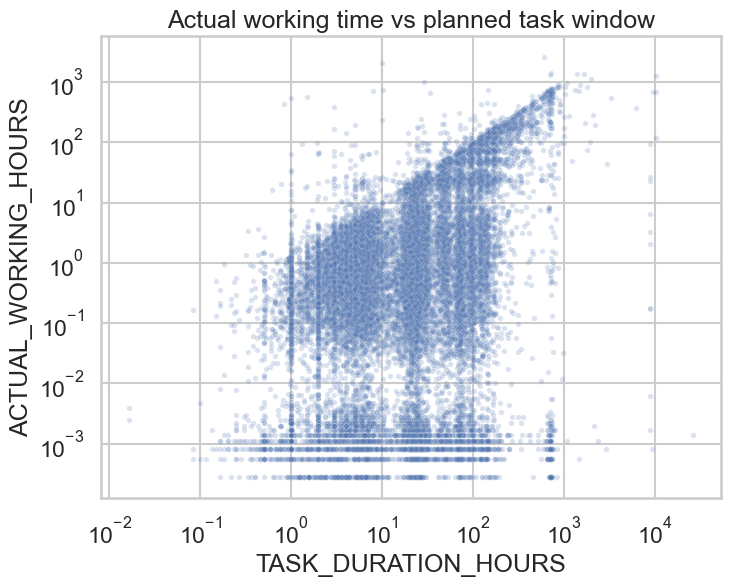

In [16]:
top_task_types = data["TASK_TYPE_CLEAN"].value_counts().head(8).index
duration_subset = enriched.loc[enriched["TASK_TYPE_CLEAN"].isin(top_task_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=duration_subset,
    x="TASK_TYPE_CLEAN",
    y="TASK_DURATION_HOURS",
    showfliers=False,
    color="#118ab2",
)
plt.xticks(rotation=35, ha="right")
plt.yscale("log")
plt.title("Task duration by task type")
plt.show()

working_sample = enriched[["TASK_DURATION_HOURS", "ACTUAL_WORKING_HOURS"]].dropna().sample(30000, random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=working_sample, x="TASK_DURATION_HOURS", y="ACTUAL_WORKING_HOURS", alpha=0.2, s=15)
plt.xscale("log")
plt.yscale("log")
plt.title("Actual working time vs planned task window")
plt.show()

,lateness_minutes
count,2.412610e+05
mean,7.688509e+02
std,1.539024e+04
min,1.666667e-02
25%,1.796667e+01
50%,4.873333e+01
75%,1.545833e+02
max,3.363861e+06


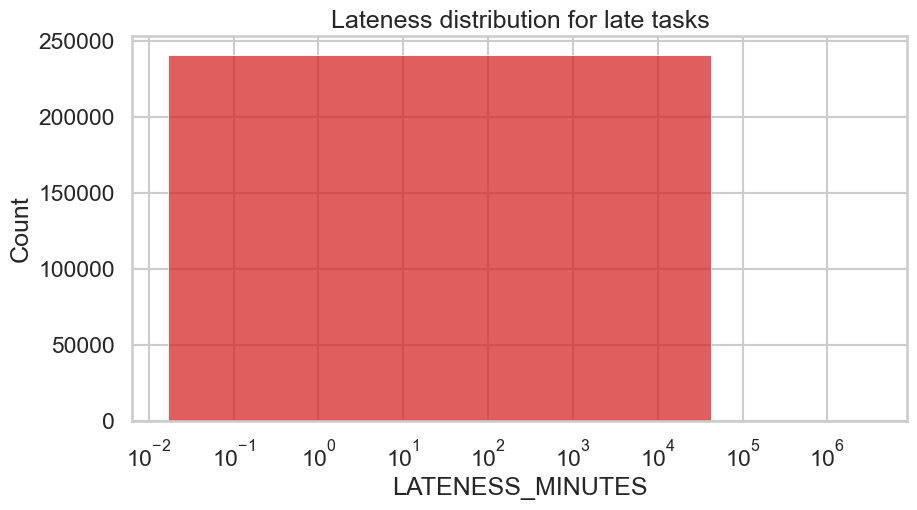

,YEAR,ON_TIME
0,2009.0,0.000000
1,2010.0,0.766319
2,2011.0,0.778659
3,2012.0,0.742860
4,2013.0,0.768416
5,2014.0,0.729080
6,2015.0,0.712076
7,2016.0,0.734188
8,2017.0,0.701959
9,2018.0,0.724614


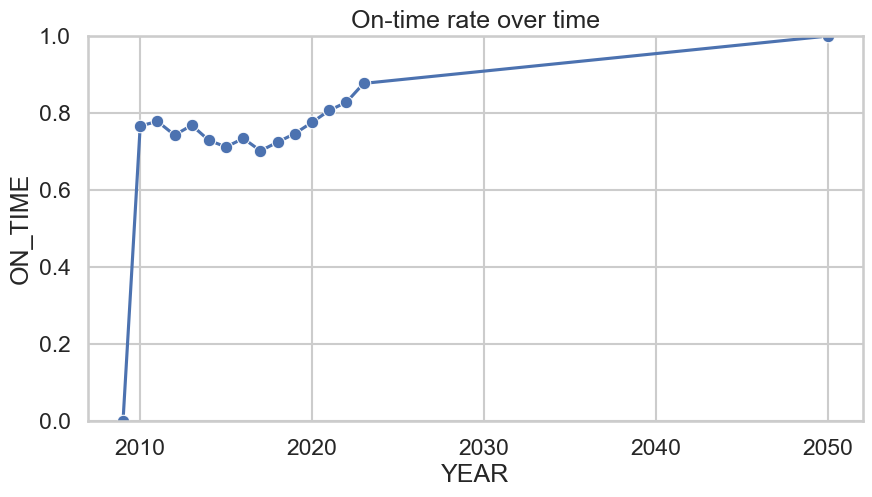

In [17]:
late_tasks = enriched.loc[enriched["LATENESS_MINUTES"] > 0, "LATENESS_MINUTES"]
display(late_tasks.describe().to_frame("lateness_minutes"))

plt.figure(figsize=(10, 5))
sns.histplot(late_tasks, bins=80, color="#d62828")
plt.xscale("log")
plt.title("Lateness distribution for late tasks")
plt.show()

on_time_over_time = (
    enriched.assign(YEAR=enriched["END"].dt.year)
    .groupby("YEAR")["ON_TIME"]
    .mean()
    .reset_index()
)
display(on_time_over_time)

plt.figure(figsize=(10, 5))
sns.lineplot(data=on_time_over_time, x="YEAR", y="ON_TIME", marker="o")
plt.ylim(0, 1)
plt.title("On-time rate over time")
plt.show()